Accuracy: 0.75
              precision    recall  f1-score   support

         Low       0.67      1.00      0.80         4
      Medium       1.00      0.43      0.60         7
        High       0.71      1.00      0.83         5

    accuracy                           0.75        16
   macro avg       0.79      0.81      0.74        16
weighted avg       0.83      0.75      0.72        16

Predicted Class: Medium


c:\Users\rajni\ml-lab\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


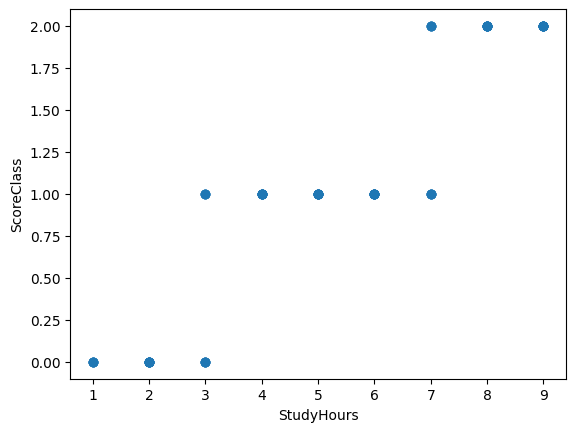

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("student_performance.csv")

# Target
score = df["Score"]
df["ScoreClass"] = np.select(
    [score < 50, (score >= 50) & (score < 75), score >= 75],
    [0, 1, 2]
)

# Features / target
X = df[["StudyHours","Attendance","SleepHours"]]
y = df["ScoreClass"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale + model
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

svm = SVC(kernel="rbf", C=1.0, gamma="scale")
svm.fit(X_train, y_train)

# Predict + evaluate
y_pred = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred,
      target_names=["Low","Medium","High"]))

# Single prediction
labels = ["Low","Medium","High"]
pred = svm.predict(scaler.transform([[6,85,7]]))[0]
print("Predicted Class:", labels[pred])

# Plot
plt.scatter(df["StudyHours"], df["ScoreClass"])
plt.xlabel("StudyHours")
plt.ylabel("ScoreClass")
plt.show()